<a href="https://colab.research.google.com/github/nelaanz/Ney/blob/main/Prediksi_Prestasi_Akademik_Siswa_Berdasarkan_Faktor_Akademik%2C_dan_Aktivitas_Non_Akademik_Menggunakan_Metode_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Student_performance_data _.csv to Student_performance_data _.csv


In [8]:
#Load Dataset

df = pd.read_csv('Student_performance_data _.csv')

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [13]:
#Data Understanding

print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

Jumlah Baris dan Kolom:
(2392, 15)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), in

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [14]:
#Cek Missing Value

print("Jumlah Missing Value:")
print(df.isnull().sum())

Jumlah Missing Value:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [15]:
#Cek dan Hapus Data Duplikat

print("Jumlah Data Duplikat :", df.duplicated().sum())

df = df.drop_duplicates()

print("Ukuran Dataset Setelah Hapus Duplikat:")
print(df.shape)

Jumlah Data Duplikat : 0
Ukuran Dataset Setelah Hapus Duplikat:
(2392, 15)


In [16]:
#Feature Engineering
#Academic Engagement Score

df['Academic_Engagement'] = (
    df['StudyTimeWeekly'] /
    (df['Absences'] + 1)
)

In [17]:
#Non Academic Activity Score


df['Activity_Score'] = (
    df['Extracurricular'] +
    df['Sports'] +
    df['Music'] +
    df['Volunteering']
)

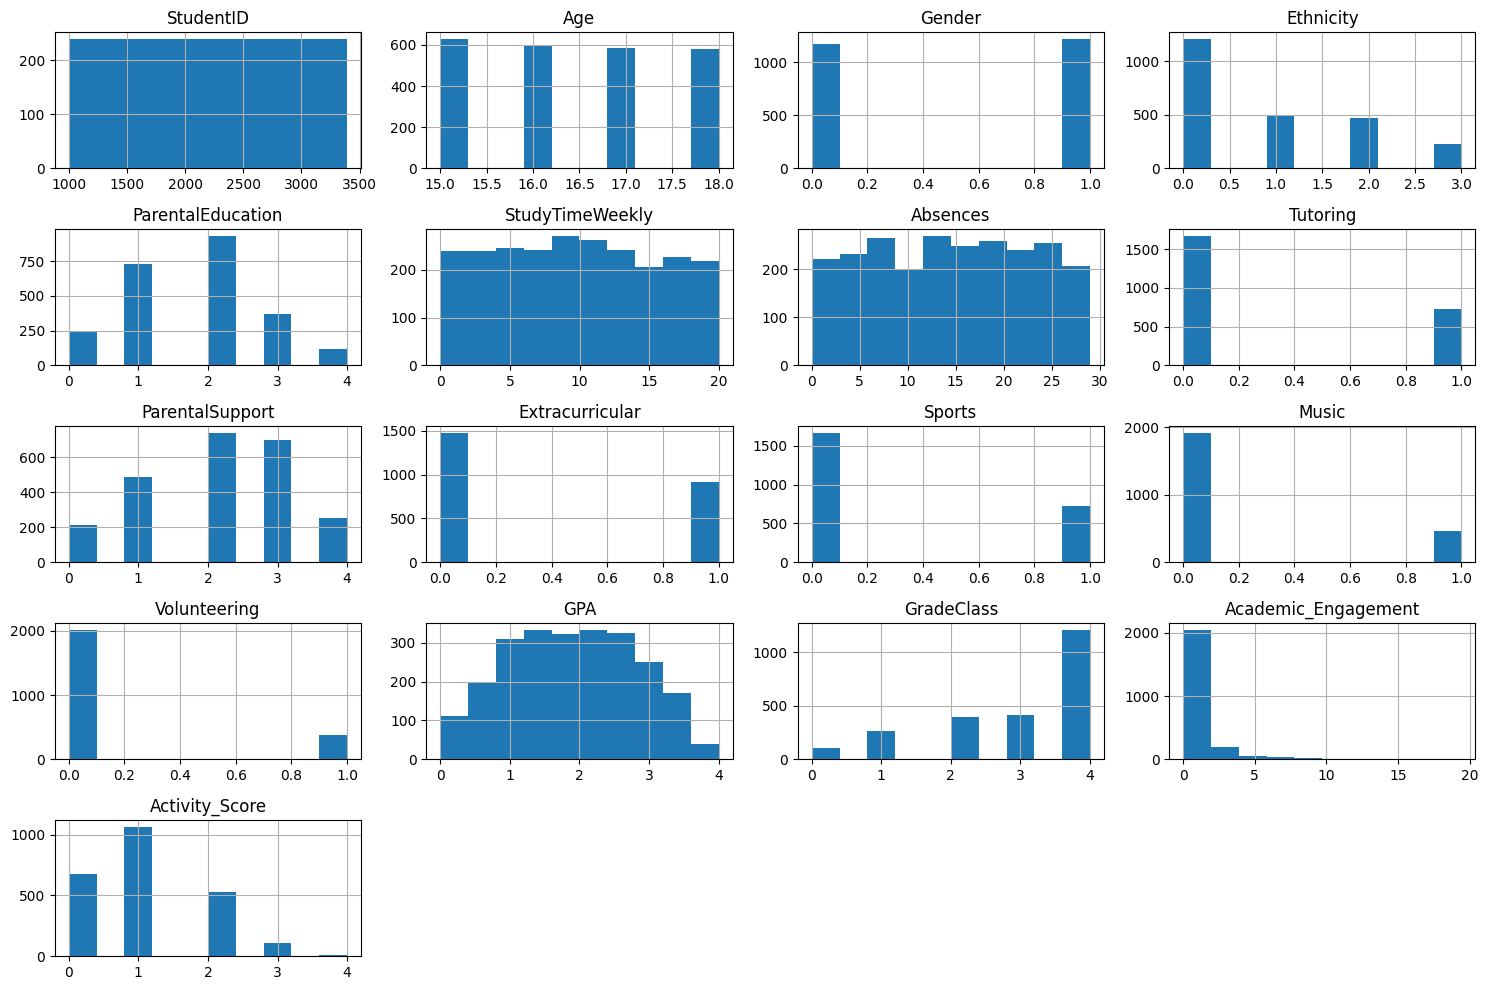

In [18]:
#Histogram

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

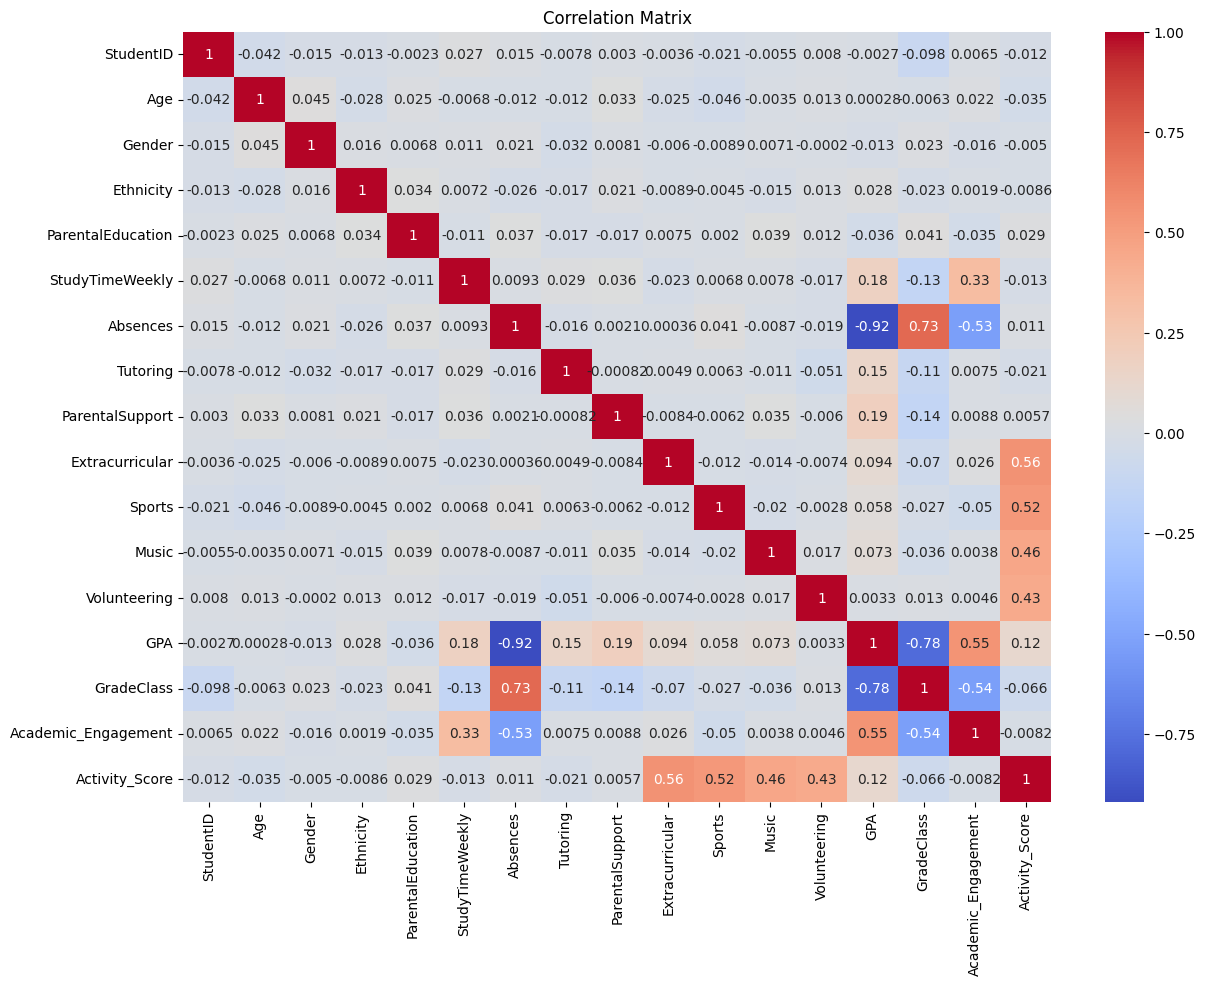

In [23]:
#Correlation Matrix

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

StudentID: 0 outlier
Age: 0 outlier
Gender: 0 outlier
Ethnicity: 0 outlier
ParentalEducation: 120 outlier
StudyTimeWeekly: 0 outlier
Absences: 0 outlier
Tutoring: 0 outlier
ParentalSupport: 0 outlier
Extracurricular: 0 outlier
Sports: 0 outlier
Music: 471 outlier
Volunteering: 376 outlier
GPA: 0 outlier
GradeClass: 0 outlier
Academic_Engagement: 261 outlier
Activity_Score: 0 outlier


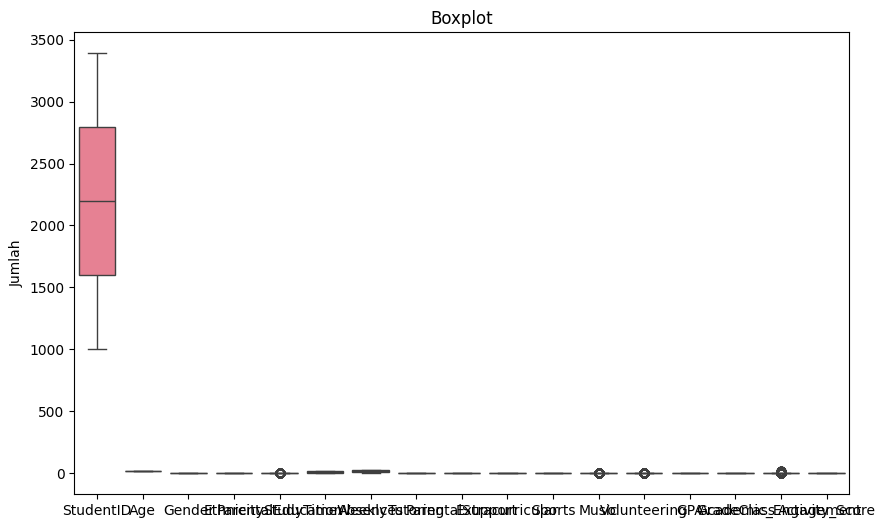

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title('Boxplot')
plt.ylabel('Jumlah')

outlier_counts = {}

for col in df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

    print(f"{col}: {len(outliers)} outlier")

plt.show()

In [24]:
#Deteksi Outlier Menggunakan IQR

numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)

Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

outlier = (
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
)

print(outlier.sum())

StudentID                0
Age                      0
Gender                   0
Ethnicity                0
ParentalEducation      120
StudyTimeWeekly          0
Absences                 0
Tutoring                 0
ParentalSupport          0
Extracurricular          0
Sports                   0
Music                  471
Volunteering           376
GPA                      0
GradeClass               0
Academic_Engagement    261
Activity_Score           0
dtype: int64


In [25]:
#penanganan Outlier

mask = ~(
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
).any(axis=1)

df = df[mask]

print(df.shape)

(1373, 17)


In [26]:
#Menentukan Variabel Target

X = df.drop(
    ['StudentID','GPA'],
    axis=1
)

y = df['GPA']

In [27]:
#Split Data Training dan Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (1098, 15)
Data Testing  : (275, 15)


In [28]:
#Normalisasi / Standardisasi Data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [29]:
#Model 1 : Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [30]:
#Model 2 : Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [31]:
#Evaluasi Linear Regression

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

mse_lr = mean_squared_error(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(
    y_test,
    pred_lr
)

print("=== Linear Regression ===")
print("MAE  :", mae_lr)
print("MSE  :", mse_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

=== Linear Regression ===
MAE  : 0.1549398491987696
MSE  : 0.03724141425203258
RMSE : 0.1929803468025503
R²   : 0.948313007251182


In [32]:
#Evaluasi Random Forest Regression

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("=== Random Forest Regression ===")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

=== Random Forest Regression ===
MAE  : 0.1669573933129823
MSE  : 0.04894754798702132
RMSE : 0.22124092746827229
R²   : 0.93206617931435


In [33]:
#Perbandingan Model

hasil = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Random Forest Regression'
    ],

    'MAE':[
        mae_lr,
        mae_rf
    ],

    'MSE':[
        mse_lr,
        mse_rf
    ],

    'RMSE':[
        rmse_lr,
        rmse_rf
    ],

    'R2':[
        r2_lr,
        r2_rf
    ]
})

hasil

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.154940,0.037241,0.192980,0.948313
1,Random Forest Regression,0.166957,0.048948,0.221241,0.932066


In [34]:
#Menentukan Model Terbaik

hasil.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.154940,0.037241,0.192980,0.948313
1,Random Forest Regression,0.166957,0.048948,0.221241,0.932066


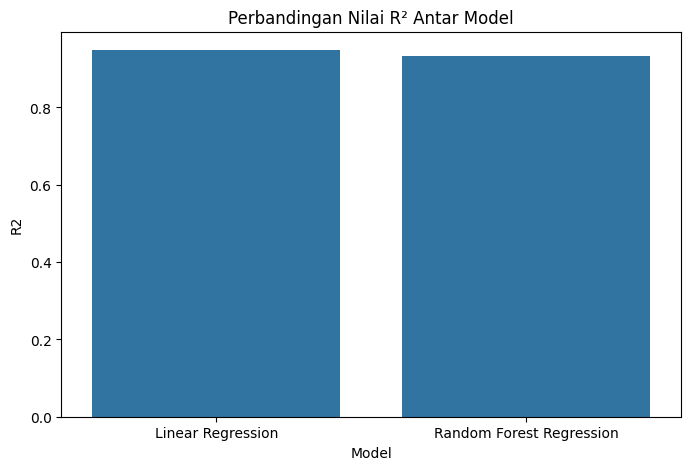

In [35]:
#Visualisasi Perbandingan Model

plt.figure(figsize=(8,5))

sns.barplot(
    data=hasil,
    x='Model',
    y='R2'
)

plt.title(
    'Perbandingan Nilai R² Antar Model'
)

plt.show()